# House Prices - Advanced Regression Techniques

## Features

Versión anterior - Boston Housing Dataset

Metadatos:


Metas:
Predecir los precios de las ventas para cada casa (para cada ID en el *test set*)
Tienes que predecir el valor de la variable *SalesPrice*

Métricas:
Se evaluan a partir del RMSE (Root Mean Squared Error) entre el logaritmo del valor predicto y el logaritmo de los precios de ventas observados.

In [2]:
import pandas as pd

In [3]:
# Importación de datos

df_entrenamiento = pd.read_csv("train.csv")
df_pruebas = pd.read_csv("test.csv")
df_muestra = pd.read_csv("sample_submission.csv")

El problema ya nos determinó los datos de entrenamiento y de prueba. En este momento vamos a trabajar con el dataset completo, realizando una exploración de sus atributos y relaciones

In [4]:
df_sector_inmobiliario = pd.concat([df_entrenamiento,df_pruebas], axis = 0)

df_sector_inmobiliario

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN


Utilizamos el dataset de entrenamiento ya que con esta información será la calidad del modelo

In [5]:
df_sector_inmobiliario.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [6]:
# Forma y tipo de datos.
df_sector_inmobiliario.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallCond  

La pregunta objetivo es:

- ¿Cuanto valdrán las casas en un futuro? | Determinar los precios de venta futuros

Siempre es bueno utilizar gráficas para dar una descripción de los datos. ¿Pero, que gráficas nos serán óptimas y que variables son importantes para su representación gráfica?

Primeramente utilizaremos una gráfica de distribución (histograma) para la variable principal *SalePrice*

In [7]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 900x800 with 0 Axes>

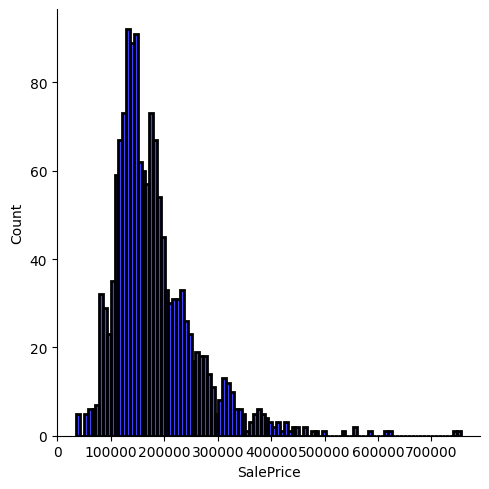

In [8]:
import seaborn as sns
from matplotlib import pyplot as plt

plt.figure(figsize=(9,8))
sns.displot(df_sector_inmobiliario['SalePrice'], color = 'b', bins = 100, edgecolor="k", linewidth=2)



In [9]:
list(set(df_sector_inmobiliario.dtypes.tolist()))



[dtype('O'), dtype('float64'), dtype('int64')]

Ya que los modelos de predicción toman tipos de valores particulares, vamos a separar los cuantitativos de los cualitativos

Los tipos de datos numericos son
- *int64* -> Discretos
- *float64* -> Flotantes

In [10]:
df_cuantitativo = df_sector_inmobiliario.select_dtypes(include=['int64','float64'])

df_cuantitativo.columns


Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

ANSWER: debido a que lo que queremos predecir son las precios de ventas, y esta variable es cuantitativa discreta, implica que es un *PROBLEMA DE REGRESIÓN*

Entonces tenemos que enfocarnos en modelos de *Aprendizaje Supervisado*

De los modelos que podemos aplicar serán:
- Regresión lineal
- Regresión polinómica
- Máquina de soporte vectorial
- Arboles de decisión y ensambles

Y sus métodos de evaluación serán:
- MSE (Error Cuadrático Medio)
- MAE (Error Absoluto Medio)
- R2 (Coeficiente de determinación)

Para esto, tenemos que determinar si vamos a realizar un preprocesamiento antes de aplicar cualquier modelo.

- Normalización y estandarización: Escalar las características de los datos para que tengan valores comparables, lo que mejora el rendimiento de ciertos algoritmos como la regresión lineal y SVR.

- Imputación de valores faltantes: Los datos incompletos pueden distorsionar los resultados del modelo, por lo que es crucial manejar los valores faltantes de manera adecuada.

- Transformaciones de características: Aplicar transformaciones como logaritmos o raíces cuadradas a las variables puede ayudar a normalizar la distribución y mejorar la capacidad del modelo para ajustarse a los datos.

La pregunta es, ¿Como sabemos si vamos a requerir algun preprocesamiento?
Al aplicar los métodos no necesitamos de tener la columna *id*

In [11]:
#df_cuantitativo = df_sector_inmobiliario.drop('Id', axis = 1)

## Regresión lineal simple

Para que la regresión lineal produzca resultados fiables, deben cumplirse ciertos supuestos:

- Linealidad: La relación entre la variable independiente y la dependiente debe ser lineal.
- Independencia de los errores: Los residuos (errores) no deben estar correlacionados entre sí.
- Varianza constante (homocedasticidad): La dispersión de los residuos debe permanecer constante en todos los valores.
- Normalidad de los residuos: Los residuos deben seguir una distribución normal.

vamos a graficar (gráficos de dispersión) las variables cuantitativas con respecto a la variable *SalePrice*



In [12]:
print(df_cuantitativo.columns)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')


In [13]:
atributo = 'GrLivArea'

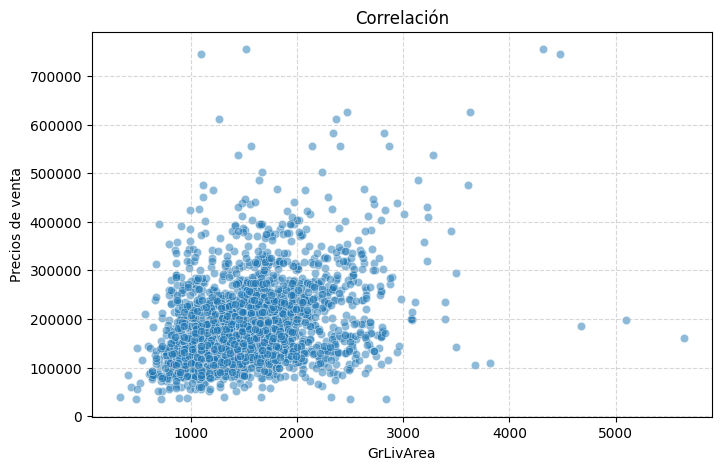

In [14]:
plt.figure(figsize = (8,5))
sns.scatterplot(data = df_cuantitativo, x=atributo , y='SalePrice', alpha = 0.5)
plt.title("Correlación")
plt.xlabel(atributo)
plt.ylabel('Precios de venta')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

Podemos ver por la gráfica varios outliers, podriamos discriminar los valores en un rango de 
- x : [0,400]
- y = [0,700]

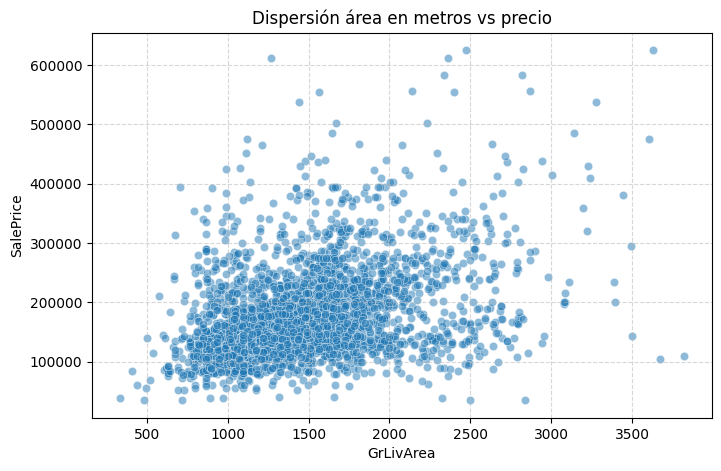

In [15]:
df_cuantitativo_filtrado = df_cuantitativo[df_cuantitativo['GrLivArea'] < 4000]

plt.figure(figsize=(8,5))
sns.scatterplot(data = df_cuantitativo_filtrado, x = atributo, y='SalePrice', alpha = 0.5)
plt.title("Dispersión área en metros vs precio")
plt.xlabel(atributo)
plt.ylabel('SalePrice')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

Esto nos dice la intuición a partir de lo que conocemos de los datos, pero que hay de las demas variables? grafiquemoslas.


In [16]:
import math

atributos = df_cuantitativo.drop("SalePrice", axis = 1)

#Determinamos cuantas columnas tendremos en nuestra malla
n_cols = 5
n_rows = math.ceil(len(atributos)/n_cols)

#Creamos el lienzo
fig, axes = plt.subplots(n_rows,n_cols,figsize= (20, n_rows*4))
axes = axes.flatten()       # Convertimos la matriz de ejes en una lista simple para iterar

for j, col in enumerate(atributos):
    sns.scatterplot(data = df_cuantitativo, x = col , y = 'SalePrice' ,ax = axes[j] , alpha = 0.4)
    
    #Estetica para evitar amontonamiento
    axes[j].set_title(f"SalePrice vs {col}",fontsize = 10)
    axes[j].set_xlabel('')
    axes[j].set_xlabel('')

#Eliminamos cuadros que sobren

for j in range(j + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

ValueError: cannot reindex on an axis with duplicate labels

Podemos hacer una segunda validación de *cuales atributos son los mejores para realizar una regresión lineal (el más óptimo, y los más óptimos).

Para esto usamos la *correlación de pearson*

In [ ]:
correlaciones = df_cuantitativo.corr()['SalePrice']

correlaciones.sort_values(ascending= False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

Trabajaremos con *OverallQuall* para la regresión lineal simple y -*GirLivArea, GarageCars, GarageArea, TotalBsmtSF* para la regresión lineal multiple

['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fen

UFuncTypeError: ufunc 'multiply' did not contain a loop with signature matching types (dtype('<U7'), dtype('float64')) -> None

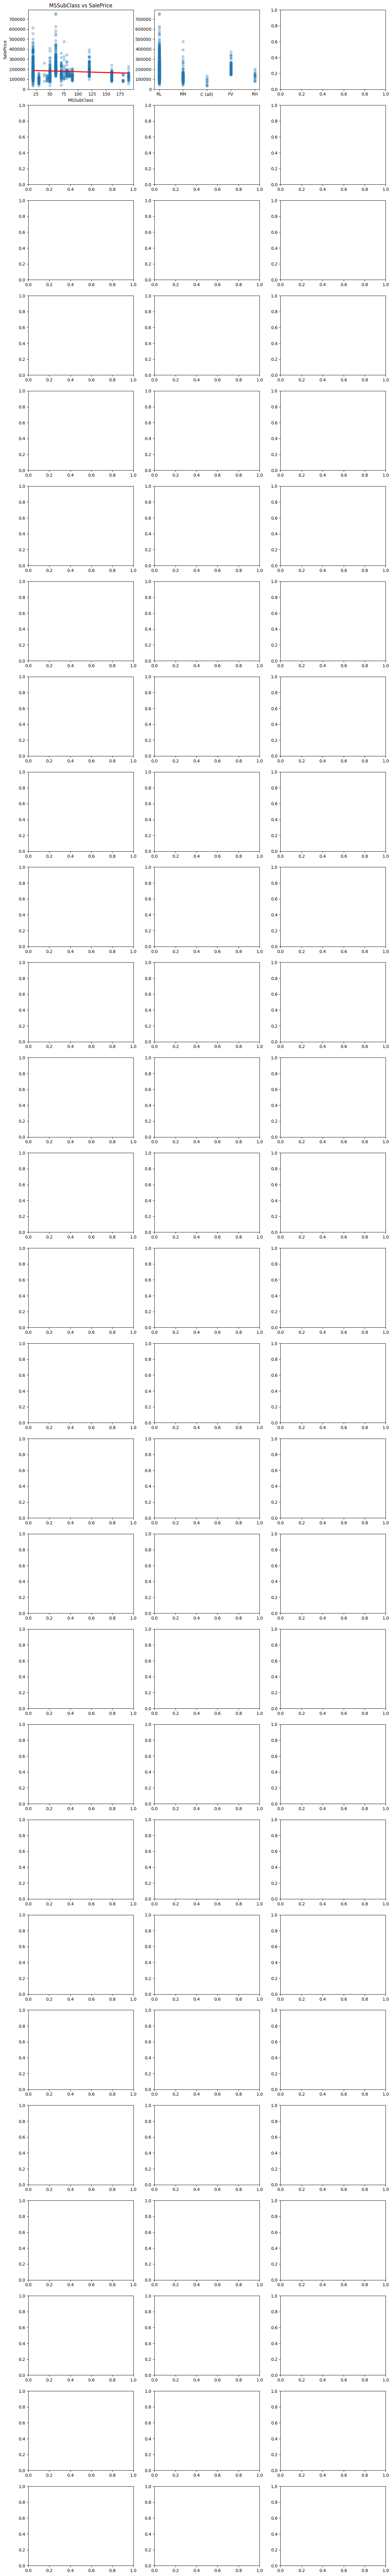

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

target = 'SalePrice'
features = [col for col in df_sector_inmobiliario.columns if col != target]
print(features)
# Calculamos cuántas filas necesitamos para la cuadrícula (3 columnas por fila)
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.regplot(x=df_sector_inmobiliario[col], y=df_sector_inmobiliario[target], ax=axes[i], 
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')

# Eliminar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [ ]:
enumerate(atributos)